## 7.2 Implementation

### 7.2.1 Neural Network as Feature Extractor

---

### **Solution Outline**

1. Train the best MLP obtained earlier.
2. Extract penultimate layer features:
   
   $$
   \phi_{NN}(x) = h^{(L-1)}(x)
   $$

3. Visualize features using t-SNE.
4. Define neural kernel:

   $$
   k(x_i, x_j) = \langle \phi_{NN}(x_i), \phi_{NN}(x_j) \rangle
   $$

5. Train Kernel SVR using this neural kernel on Phase 4 data.

---

### **Mathematical Formulation**

Given an MLP:

$$
h^{(l)}(x) = \sigma^{(l)}\left(W^{(l)} h^{(l-1)}(x) + b^{(l)}\right)
$$

Final prediction:

$$
f(x) = W^{(L)} h^{(L-1)}(x)
$$

We define learned feature map:

$$
\phi_{NN}(x) := h^{(L-1)}(x)
$$

Neural kernel:

$$
k(x_i, x_j) = \phi_{NN}(x_i)^\top \phi_{NN}(x_j)
$$

---

### **Implementation Steps**

- Train MLP
- Extract features:
  
  $$
  \Phi = \{\phi_{NN}(x_i)\}_{i=1}^n
  $$

- Compute Gram matrix:

  $$
  K_{ij} = k(x_i, x_j)
  $$

- Train SVR using precomputed kernel.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Add path to mlp.py
sys.path.append(r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\mlp")

from mlp import MLP

In [2]:
# ----------------------------
# Load dataset
# ----------------------------
df = pd.read_csv(r"C:\Users\PUSHKAR\Desktop\DL-Assignments\Assignment-1\iit_h_mess_dataset.csv")

X = df.drop(columns=["mess_duration"]).values
y = df["mess_duration"].values.reshape(-1, 1)

In [3]:
# train / val / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [4]:
# feature scaling (CRITICAL)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled   = y_scaler.transform(y_val)
y_test_scaled  = y_scaler.transform(y_test)

In [5]:
layer_sizes = [X_train.shape[1], 64, 64, 1]
activations = ["tanh", "tanh", "tanh"]

model = MLP(
    layer_sizes=layer_sizes,
    activations=activations,
    learning_rate=0.01
)

In [6]:
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_pred - y_true
    abs_error = np.abs(error)

    quadratic = np.minimum(abs_error, delta)
    linear = abs_error - quadratic

    return np.mean(0.5 * quadratic**2 + delta * linear)


def huber_grad(y_true, y_pred, delta=1.0):
    error = y_pred - y_true
    grad = np.where(np.abs(error) <= delta, error, delta * np.sign(error))
    return grad

In [7]:
lambda_l2 = 0.01
epochs = 500

loss_history = []

for _ in range(epochs):

    # Forward
    y_pred = model.forward(X_train)

    # Compute Huber loss
    loss = huber_loss(y_train_scaled.T, y_pred)
    loss_history.append(loss)

    # Compute gradient of loss wrt output
    dA = huber_grad(y_train_scaled.T, y_pred)

    grads_W = {}
    grads_b = {}

    m = X_train.shape[0]

    # Backprop
    for l in reversed(range(1, model.L + 1)):
        dZ = dA * model.act_deriv[l](model.Z[l])
        grads_W[l] = (1/m) * dZ @ model.A[l-1].T
        grads_b[l] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        # L2 regularization
        grads_W[l] += lambda_l2 * model.W[l]

        dA = model.W[l].T @ dZ

    # Update
    for l in range(1, model.L + 1):
        model.W[l] -= model.optimizer.lr * grads_W[l]
        model.b[l] -= model.optimizer.lr * grads_b[l]

In [8]:
# Save trained neural network before using 'model' for other things
nn_model = model

In [9]:
def extract_features(model, X):
    model.forward(X)
    L_minus_1 = model.L - 1
    return model.A[L_minus_1].T

Phi_train = extract_features(model, X_train)
Phi_test  = extract_features(model, X_test)

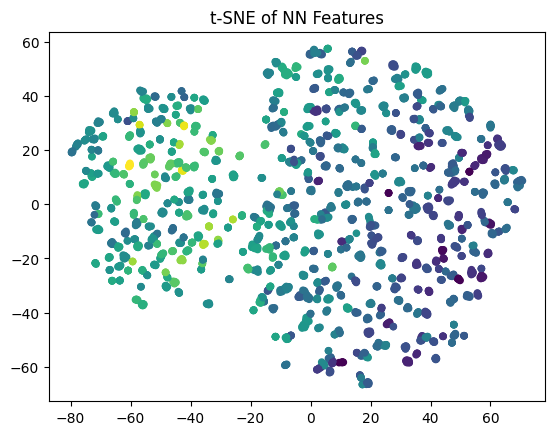

In [10]:
tsne = TSNE(n_components=2, random_state=42)
Phi_2d = tsne.fit_transform(Phi_train)

plt.figure()
plt.scatter(Phi_2d[:,0], Phi_2d[:,1], c=y_train.flatten(), s=20)
plt.title("t-SNE of NN Features")
plt.show()

In [11]:
def neural_kernel_matrix(Phi_A, Phi_B):
    return Phi_A @ Phi_B.T

K_train = neural_kernel_matrix(Phi_train, Phi_train)
K_test  = neural_kernel_matrix(Phi_test, Phi_train)

In [12]:
svr = SVR(kernel='precomputed', C=1.0, epsilon=0.1)
svr.fit(K_train, y_train_scaled.ravel())

y_pred_scaled = svr.predict(K_test)

# Inverse scaling
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1))

mse = mean_squared_error(y_test, y_pred)
print("Neural Kernel SVR Test MSE:", mse)

Neural Kernel SVR Test MSE: 24.75984893838342


## 7.2.2 Comparison with Standard Kernels

We compare the following kernels for Support Vector Regression (SVR):

### Kernels

**(a) Linear Kernel**
$$
k(x_i,x_j) = x_i^T x_j
$$

**(b) Polynomial Kernel**
$$
k(x_i,x_j) = (x_i^T x_j + c)^d, \quad d \in \{2,3\}
$$

**(c) RBF (Gaussian) Kernel**
$$
k(x_i,x_j) = \exp(-\gamma \|x_i - x_j\|^2),
\quad \gamma \in \{0.01, 0.1, 1.0\}
$$

**(d) Neural Kernel**
$$
k(x_i,x_j) = \phi_{NN}(x_i)^T \phi_{NN}(x_j)
$$

where
$$
\phi_{NN}(x) = h^{(L-1)}(x)
$$

---

### For each kernel:

- Report test MSE
- Plot 2D decision surface (via PCA projection)
- Visualize kernel matrix:
  $$
  K_{ij} = k(x_i,x_j)
  $$

In [13]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import rbf_kernel

In [14]:
def linear_kernel_matrix(XA, XB):
    return XA @ XB.T

def polynomial_kernel_matrix(XA, XB, degree=2, c=1):
    return (XA @ XB.T + c) ** degree

def rbf_kernel_matrix(XA, XB, gamma=0.1):
    return rbf_kernel(XA, XB, gamma=gamma)

def neural_kernel_matrix(PhiA, PhiB):
    return PhiA @ PhiB.T

In [15]:
# ================================
# Kernel Matrix Visualization
# ================================

def plot_kernel_matrix(K, title):

    K_norm = (K - K.min()) / (K.max() - K.min())

    plt.figure(figsize=(6,5))
    plt.imshow(K_norm, cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("j")
    plt.ylabel("i")
    plt.show()


In [16]:
# ================================
# Decision Surface Plot
# ================================

def plot_decision_surface(X, y, model, name):

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    x_min, x_max = X_2d[:,0].min()-1, X_2d[:,0].max()+1
    y_min, y_max = X_2d[:,1].min()-1, X_2d[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 80),
        np.linspace(y_min, y_max, 80)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_orig = pca.inverse_transform(grid)

    Z = model.predict(grid_orig)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, levels=50)
    plt.scatter(X_2d[:,0], X_2d[:,1], c=y.flatten(), edgecolors='k')
    plt.title(name)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

In [17]:
# =========================
# Train + Evaluate
# =========================

def train_evaluate_kernel(model, X_train, X_test, y_train, y_test, name):

    model.fit(X_train, y_train.ravel())

    y_pred_scaled = model.predict(X_test)

    y_pred = y_scaler.inverse_transform(
        y_pred_scaled.reshape(-1,1)
    )

    mse = mean_squared_error(y_test, y_pred)

    print(f"{name} Test MSE: {mse:.4f}")

    return mse, model

In [18]:
results = {}
models = {}

# subset for kernel visualization
N = 200
X_sub = X_train[:N]

Linear Kernel Test MSE: 26.9461


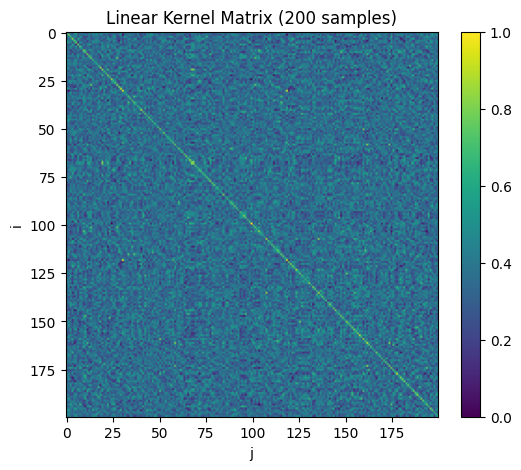

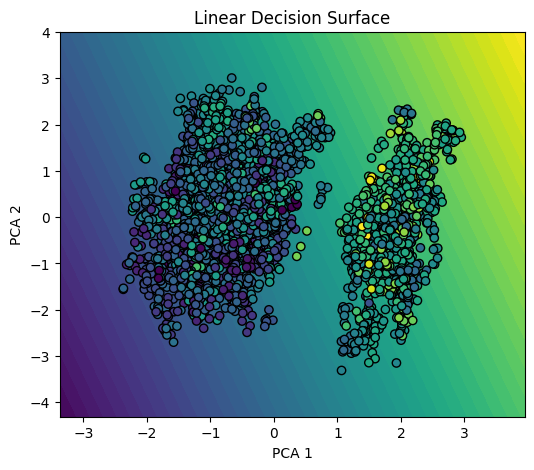

In [19]:
# linear kernel

model = SVR(kernel='linear', C=1.0, epsilon=0.1)

mse, model = train_evaluate_kernel(
    model,
    X_train, X_test,
    y_train_scaled, y_test,
    "Linear Kernel"
)

results["Linear"] = mse
models["Linear"] = model

K_vis = linear_kernel_matrix(X_sub, X_sub)
plot_kernel_matrix(K_vis, "Linear Kernel Matrix (200 samples)")

plot_decision_surface(X_train, y_train, model, "Linear Decision Surface")

Polynomial Kernel (d=2) Test MSE: 51.3583


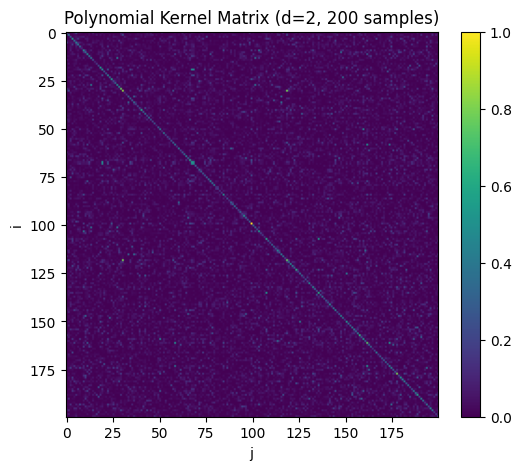

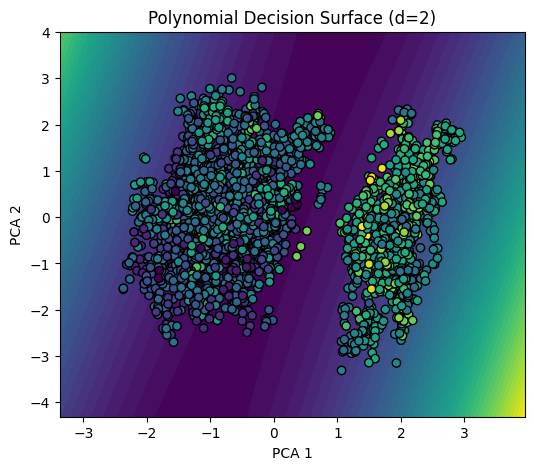

Polynomial Kernel (d=3) Test MSE: 11.6180


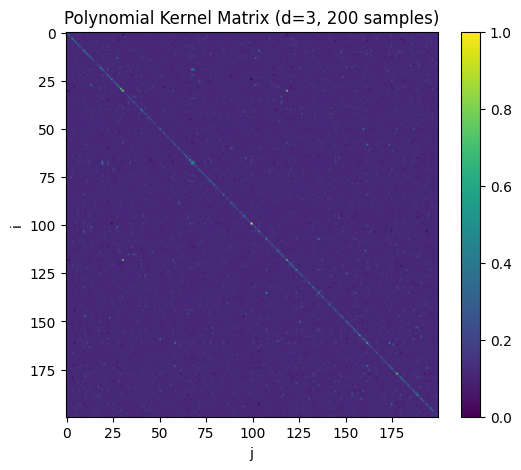

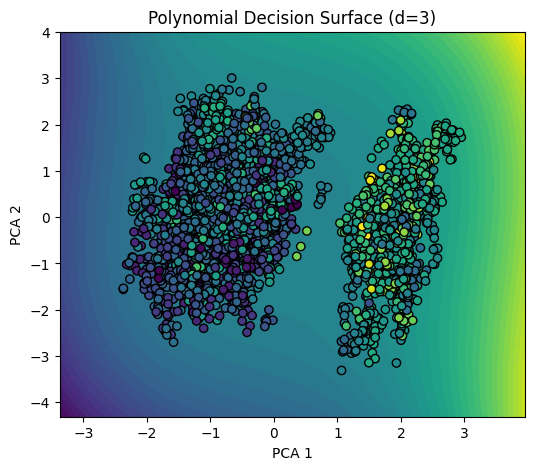

In [20]:
# Polynomial kernel

for d in [2,3]:

    model = SVR(kernel='poly', degree=d, C=1.0, epsilon=0.1)

    mse, model = train_evaluate_kernel(
        model,
        X_train, X_test,
        y_train_scaled, y_test,
        f"Polynomial Kernel (d={d})"
    )

    results[f"Poly_d{d}"] = mse
    models[f"Poly_d{d}"] = model

    K_vis = polynomial_kernel_matrix(X_sub, X_sub, degree=d)
    plot_kernel_matrix(K_vis, f"Polynomial Kernel Matrix (d={d}, 200 samples)")

    plot_decision_surface(X_train, y_train, model,
                          f"Polynomial Decision Surface (d={d})")

RBF Kernel (gamma=0.01) Test MSE: 24.5363


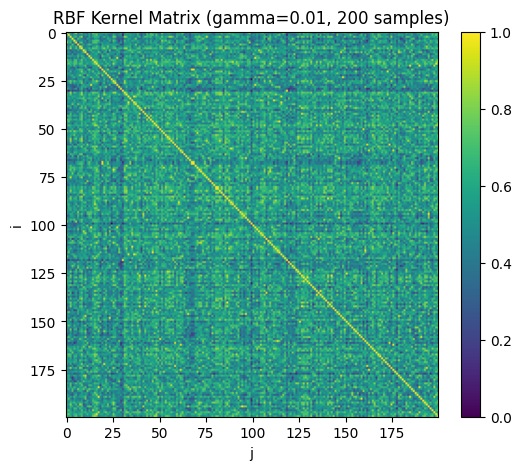

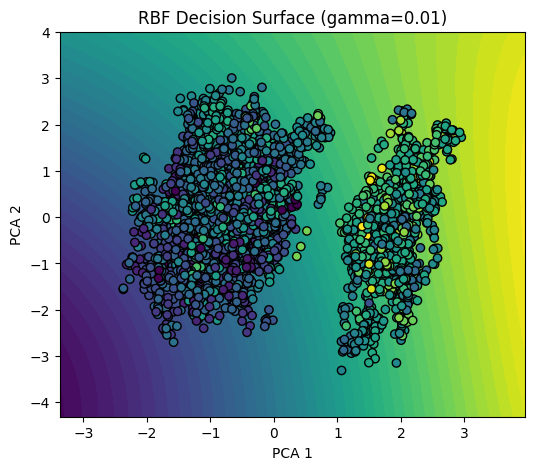

RBF Kernel (gamma=0.1) Test MSE: 3.7478


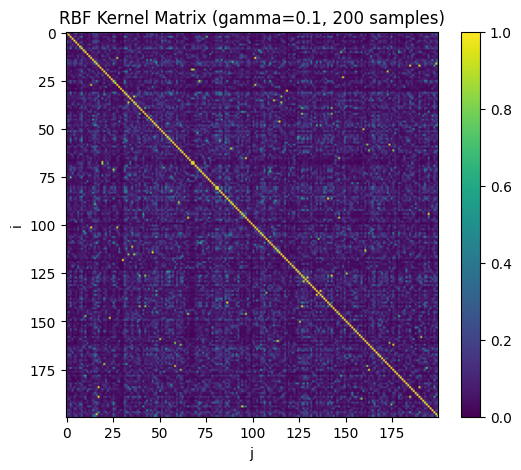

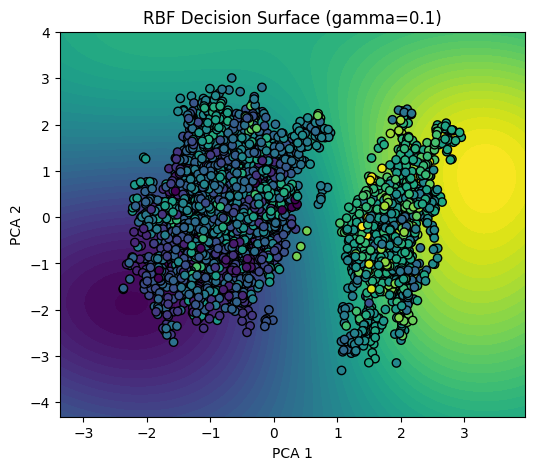

RBF Kernel (gamma=1.0) Test MSE: 10.1648


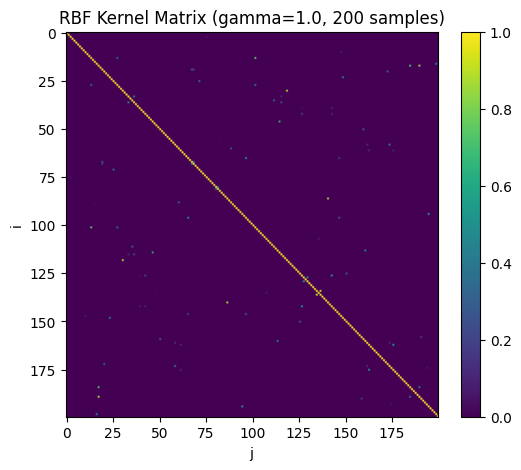

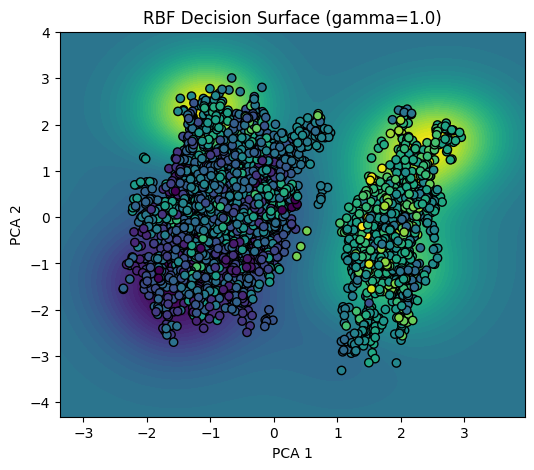

In [21]:
# rbf kernel

for gamma in [0.01, 0.1, 1.0]:

    model = SVR(kernel='rbf', gamma=gamma, C=1.0, epsilon=0.1)

    mse, model = train_evaluate_kernel(
        model,
        X_train, X_test,
        y_train_scaled, y_test,
        f"RBF Kernel (gamma={gamma})"
    )

    results[f"RBF_gamma{gamma}"] = mse
    models[f"RBF_gamma{gamma}"] = model

    K_vis = rbf_kernel_matrix(X_sub, X_sub, gamma=gamma)
    plot_kernel_matrix(K_vis, f"RBF Kernel Matrix (gamma={gamma}, 200 samples)")

    plot_decision_surface(X_train, y_train, model,
                          f"RBF Decision Surface (gamma={gamma})")


Neural Kernel SVR Test MSE: 24.75984893838342


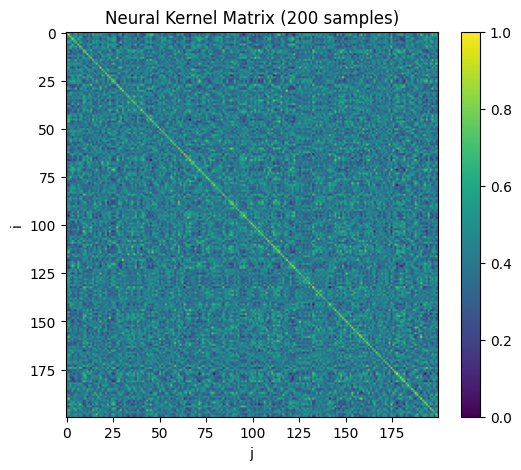

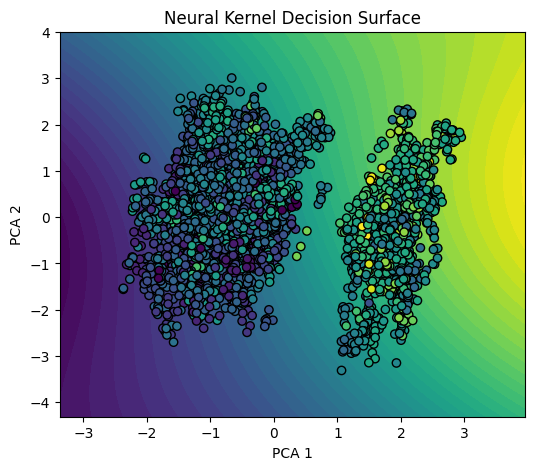

In [23]:
# ================================
# Neural Kernel
# ================================

# --- Extract NN features ---
Phi_train = extract_features(nn_model, X_train)
Phi_test  = extract_features(nn_model, X_test)


# --- Neural kernel matrices ---
K_train = neural_kernel_matrix(Phi_train, Phi_train)
K_test  = neural_kernel_matrix(Phi_test, Phi_train)


# --- Train SVR ---
svr = SVR(kernel='precomputed', C=1.0, epsilon=0.1)
svr.fit(K_train, y_train_scaled.ravel())

y_pred_scaled = svr.predict(K_test)

y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1))

mse = mean_squared_error(y_test, y_pred)

print("Neural Kernel SVR Test MSE:", mse)

results["Neural"] = mse
models["Neural"] = svr


# ================================
# Kernel Matrix Visualization
# ================================

Phi_sub = extract_features(nn_model, X_sub)
K_vis = neural_kernel_matrix(Phi_sub, Phi_sub)

plot_kernel_matrix(K_vis, "Neural Kernel Matrix (200 samples)")


# ================================
# Decision Surface (Neural Kernel)
# ================================

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train)

x_min, x_max = X_2d[:,0].min()-1, X_2d[:,0].max()+1
y_min, y_max = X_2d[:,1].min()-1, X_2d[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 80),
    np.linspace(y_min, y_max, 80)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_orig = pca.inverse_transform(grid)

# Extract NN features for grid and training set
Phi_grid  = extract_features(nn_model, grid_orig)
Phi_train = extract_features(nn_model, X_train)

# Compute neural kernel
K_grid = neural_kernel_matrix(Phi_grid, Phi_train)

Z = svr.predict(K_grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, levels=50)
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_train.flatten(), edgecolors='k')
plt.title("Neural Kernel Decision Surface")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [24]:
print("\nFinal Comparison:")

for k,v in results.items():
    print(f"{k}: {v:.4f}")


Final Comparison:
Linear: 26.9461
Poly_d2: 51.3583
Poly_d3: 11.6180
RBF_gamma0.01: 24.5363
RBF_gamma0.1: 3.7478
RBF_gamma1.0: 10.1648
Neural: 24.7598
